In [ ]:
from flower_model._kmeans import _spherical_kmeans
from flower_model.external._gabor_like_filters import _gabor_like_filters
from flower_model._cosine_similarity import _cosine_similarity
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import ImageFolder
import math
import numpy as np

In [2]:
N = 127
sigma = 150.
device = 'cuda'
k = 100
SPH_KMEANS_ITERS = 1000

filters = _gabor_like_filters(N, sigma)
print(filters.shape)

/cluster/home/vetletb/projects/Bacheloroppgave-gr82-feature-extraction/src/gabor_like/external/_gaussian.py:21: RuntimeWarning: invalid value encountered in divide
  (n + np.array([l1, l2]).reshape(-1, 1, 1))


(1345, 127, 127)


In [3]:
filters = filters.astype("complex64")
filters = torch.tensor(filters, device=device)

abs_filters = torch.abs(filters)


filter_amount = filters.size(dim=0)
filters = filters.view(filter_amount, -1)
abs_filters = abs_filters.view(filter_amount, -1)

labels = _spherical_kmeans(k, abs_filters, SPH_KMEANS_ITERS)

In [4]:
filters_list = []

filters_list.append(filters.real)
filters_list.append(filters.imag)

filters = torch.vstack(filters_list)

filters_normalized = torch.nn.functional.normalize(filters, dim=1)

In [5]:
transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((N+1, N+1)),
        transforms.ToTensor(),
    ]
)
dataset = ImageFolder(root="image", transform=transform)

loader = torch.utils.data.DataLoader(
    dataset, batch_size=2, shuffle=False, pin_memory=True
)

it = iter(loader)
image = next(it)
image = image[0].to(device=device)

print(image.shape)

torch.Size([2, 1, 128, 128])


In [7]:
print(labels.shape)

# max_coeff_list = []
# for i in range(k):
#     for j in range(4):
#         sample = features[:, j::4]
#         coeff_in_cluster = sample[:, labels == i]
#         if coeff_in_cluster.size(dim=1) == 0:
#             continue
#         max_coeff = torch.amax(coeff_in_cluster, dim=1)
#         max_coeff_list.append(max_coeff)

# features = torch.stack(max_coeff_list, dim=1)

# print(features.shape)

# features = features.view(2, k*4, -1)

actual_k = torch.unique(labels).numel()
print(actual_k)

max_coeff = torch.empty(
    (2, actual_k, (N+1)*(N+1)),
    device=device,
)

# for i in range(actual_k):
#     for j in range(4):
#         sample = features[:, j::4]
#         coeff_in_cluster = sample[:, labels == i]
#         if coeff_in_cluster.size(dim=1) == 0:
#             continue
#         max_coeff[:, i*4 + j, :] = torch.amax(coeff_in_cluster, dim=1)
# del sample, coeff_in_cluster

labels_expanded = labels.repeat_interleave(4)

# for i in range(actual_k):
#     mask = (labels_expanded == i)
#     if mask.sum() == 0:
#         continue

#     coeff_in_cluster = features[:, mask, :]
#     max_coeff[:, i, :] = coeff_in_cluster.amax(dim=1)
#     del coeff_in_cluster

write_idx = 0
for i in range(k):
    mask = (labels_expanded == i)
    if mask.sum() == 0:
        continue
    coeff_in_cluster = features[:, mask, :]
    max_coeff[:, write_idx, :] = coeff_in_cluster.amax(dim=1)
    write_idx += 1
    del coeff_in_cluster
print(max_coeff.shape)
features = max_coeff


torch.Size([1345])
100
torch.Size([2, 100, 16384])


In [8]:
image = features[0].view(1, actual_k, -1)
print(features.shape)

torch.Size([2, 100, 16384])


torch.Size([100, 16384])


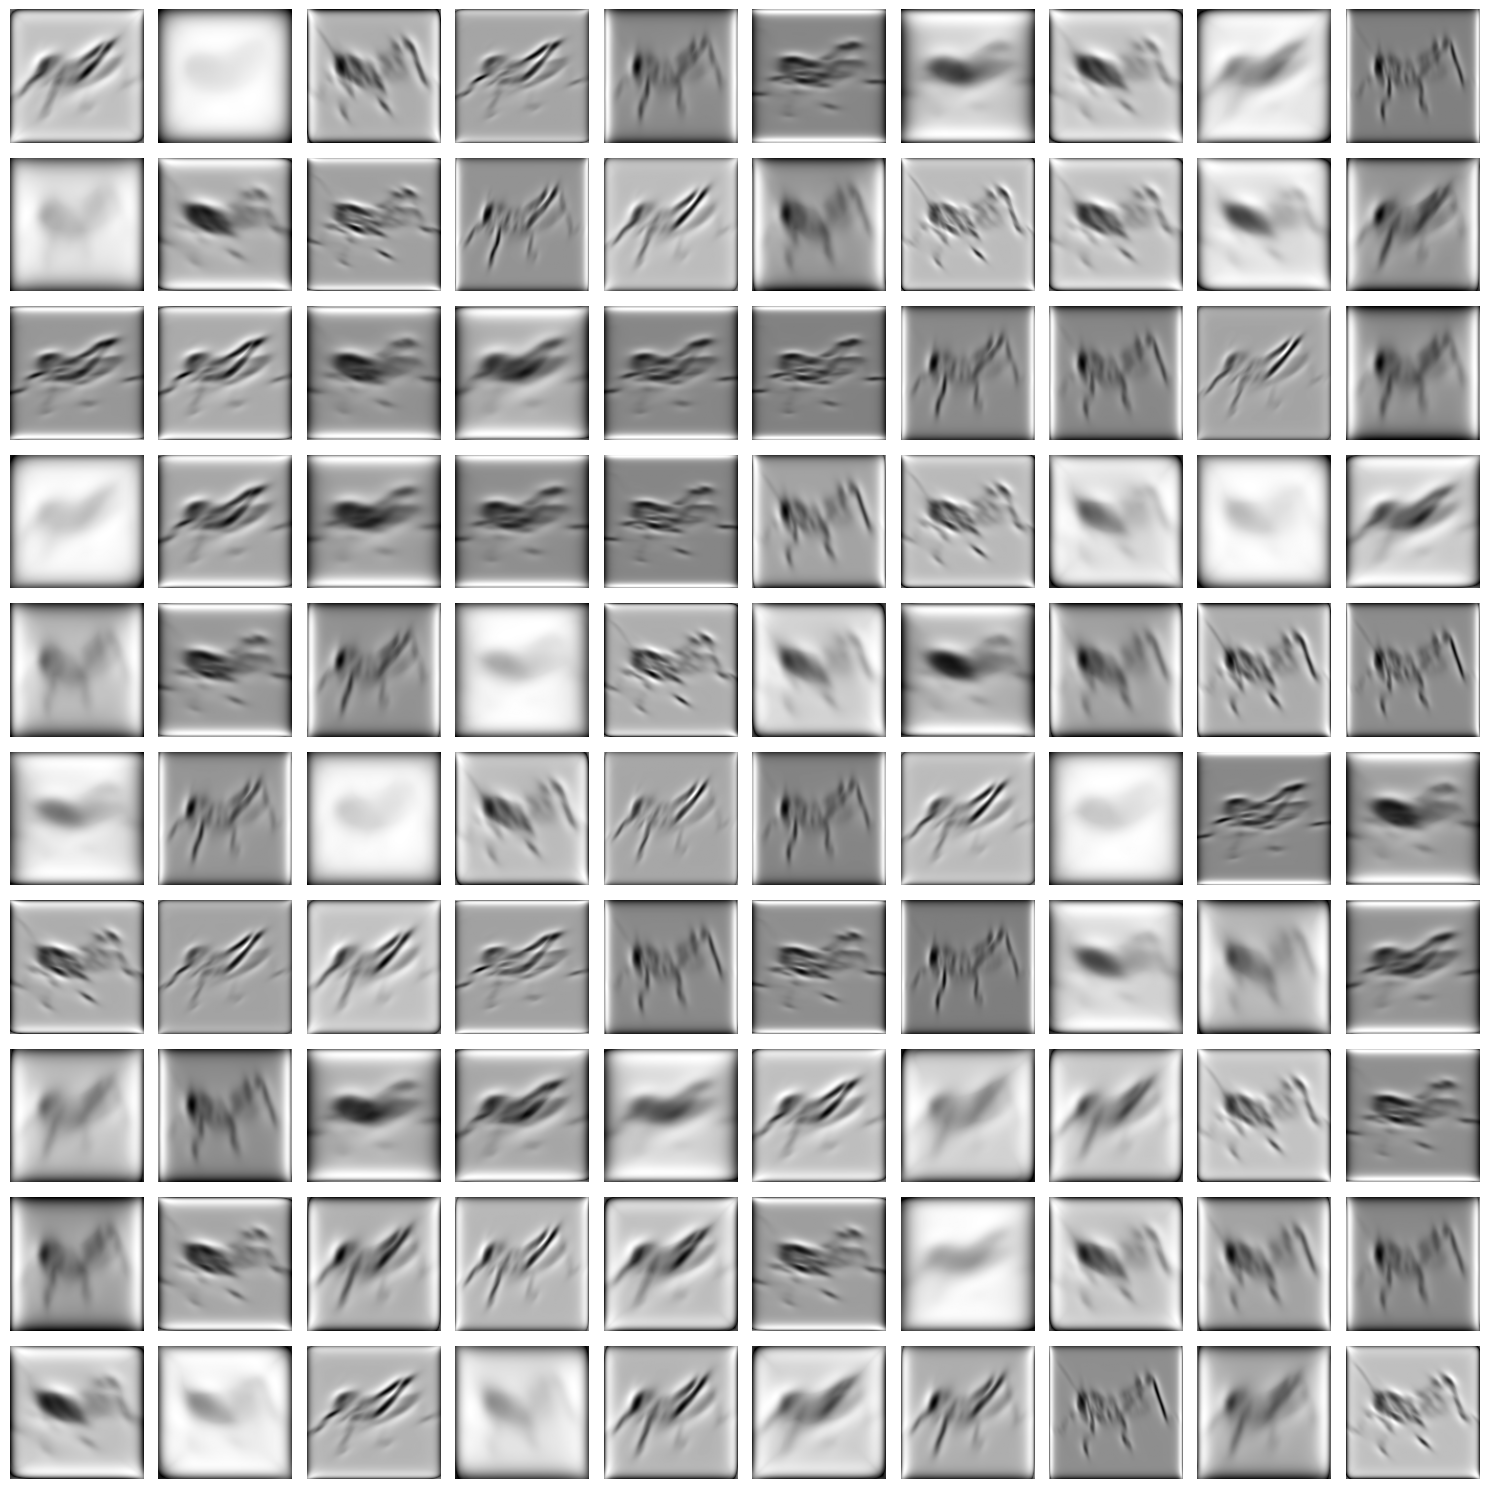

In [9]:
f = image.squeeze(0).cpu()        # shape [N, 1024]
print(f.shape)
n = f.shape[0]
size = int(math.sqrt(f.shape[1]))
assert size * size == f.shape[1], "expected square (H*W)"

cols = int(math.ceil(math.sqrt(n)))
rows = int(math.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
axes = np.atleast_1d(axes).flatten()

for i in range(rows * cols):
    ax = axes[i]
    if i < n:
        img = f[i].reshape(size, size).numpy()
        ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()